In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\besho\OneDrive\Desktop\project\SIC_P1\dataset\housing_data_CDMX.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18234 entries, 0 to 18233
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_type               18234 non-null  str    
 1   places                      18234 non-null  str    
 2   lat-lon                     18234 non-null  str    
 3   price                       18234 non-null  float64
 4   currency                    18234 non-null  str    
 5   price_aprox_local_currency  18234 non-null  float64
 6   price_aprox_usd             18234 non-null  float64
 7   surface_total_in_m2         18234 non-null  float64
 8   surface_covered_in_m2       18234 non-null  float64
 9   price_usd_per_m2            18234 non-null  float64
 10  price_per_m2                18234 non-null  float64
dtypes: float64(7), str(4)
memory usage: 1.5 MB


In [4]:
df.head()

,property_type,places,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2
0,apartment,MiguelHidalgo,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,54.0,54.0,5366.215926,101851.85190
1,house,Iztapalapa,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,80.0,80.0,995.774500,18900.00000
2,apartment,Tlalpan,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,100.0,100.0,488.228200,9266.67000
3,apartment,MiguelHidalgo,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,135.0,135.0,2501.632296,47481.48148
4,apartment,MiguelHidalgo,"19.432657,-99.177444",4416000.0,MXN,4376051.62,232663.51,87.0,87.0,2674.293218,50758.62069


# Duplicated and nulls handling

In [5]:
df.duplicated().sum()

np.int64(2953)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.isnull().sum()

property_type                 0
places                        0
lat-lon                       0
price                         0
currency                      0
price_aprox_local_currency    0
price_aprox_usd               0
surface_total_in_m2           0
surface_covered_in_m2         0
price_usd_per_m2              0
price_per_m2                  0
dtype: int64

# split lat-lon column to two column

In [8]:
df[['latitude', 'longitude']] = df['lat-lon'].str.split(',', expand=True)

df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

df.drop('lat-lon', axis=1, inplace=True)

Chack nulls for new columns

In [9]:
df.isnull().sum()

property_type                   0
places                          0
price                           0
currency                        0
price_aprox_local_currency      0
price_aprox_usd                 0
surface_total_in_m2             0
surface_covered_in_m2           0
price_usd_per_m2                0
price_per_m2                    0
latitude                      103
longitude                     103
dtype: int64

In [10]:
df = df.dropna(subset=['latitude', 'longitude'])

In [11]:
df.head()

,property_type,places,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
0,apartment,MiguelHidalgo,5500000.0,MXN,5450245.50,289775.66,54.0,54.0,5366.215926,101851.85190,23.634501,-102.552788
1,house,Iztapalapa,1512000.0,MXN,1498321.97,79661.96,80.0,80.0,995.774500,18900.00000,19.310330,-99.068557
2,apartment,Tlalpan,926667.0,MXN,918284.00,48822.82,100.0,100.0,488.228200,9266.67000,19.279771,-99.234597
3,apartment,MiguelHidalgo,6410000.0,MXN,6352013.39,337720.36,135.0,135.0,2501.632296,47481.48148,23.634501,-102.552788
4,apartment,MiguelHidalgo,4416000.0,MXN,4376051.62,232663.51,87.0,87.0,2674.293218,50758.62069,19.432657,-99.177444


# outliers handling

In [12]:
num_cols = df.select_dtypes(include=['number']).columns

print("Numerical columns:", num_cols)

df[num_cols].describe().round()

Numerical columns: Index(['price', 'price_aprox_local_currency', 'price_aprox_usd',
       'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2',
       'price_per_m2', 'latitude', 'longitude'],
      dtype='str')


,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
count,15178.0,15178.0,15178.0,15178.0,15178.0,15178.0,15178.0,15178.0,15178.0
mean,3756191.0,5497853.0,292307.0,4857.0,4830.0,1510.0,24335.0,19.0,-99.0
std,5885216.0,10305725.0,547929.0,534076.0,534074.0,2287.0,43688.0,1.0,0.0
min,7000.0,109031.0,5797.0,1.0,1.0,0.0,0.0,19.0,-103.0
25%,1030000.0,1090307.0,57969.0,70.0,70.0,660.0,11125.0,19.0,-99.0
50%,2000000.0,2308625.0,122744.0,100.0,100.0,1068.0,17792.0,19.0,-99.0
75%,4110000.0,4955944.0,263495.0,205.0,218.0,1900.0,32000.0,19.0,-99.0
max,233726700.0,336484065.0,17890000.0,65748000.0,65748000.0,175918.0,3338953.0,42.0,-90.0


In [13]:
df.shape

(15178, 12)

In [14]:
num_cols = [
    'price',
    'price_aprox_local_currency',
    'price_aprox_usd',
    'surface_total_in_m2',
    'surface_covered_in_m2',
    'price_usd_per_m2',
    'price_per_m2'
]

mask = pd.Series(True, index=df.index)

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    mask &= df[col].between(lower,df[col].max())

    print(f"{col}: {outliers} outliers")

df = df[mask]

price: 1384 outliers
price_aprox_local_currency: 1936 outliers
price_aprox_usd: 1936 outliers
surface_total_in_m2: 1395 outliers
surface_covered_in_m2: 1290 outliers
price_usd_per_m2: 805 outliers
price_per_m2: 500 outliers


In [15]:
df.shape

(15178, 12)

In [16]:
df[num_cols] = df[num_cols].round(1)

In [17]:
df.describe()

,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
count,1.517800e+04,1.517800e+04,1.517800e+04,1.517800e+04,1.517800e+04,15178.000000,1.517800e+04,15178.000000,15178.000000
mean,3.756191e+06,5.497853e+06,2.923068e+05,4.857062e+03,4.829817e+03,1509.830116,2.433529e+04,19.440262,-99.206676
std,5.885216e+06,1.030572e+07,5.479291e+05,5.340756e+05,5.340743e+05,2287.031875,4.368838e+04,0.510603,0.398425
min,7.000000e+03,1.090306e+05,5.796900e+03,1.000000e+00,1.000000e+00,0.000000,0.000000e+00,19.185852,-102.552788
25%,1.030000e+06,1.090308e+06,5.796890e+04,7.000000e+01,7.000000e+01,659.900000,1.112478e+04,19.350214,-99.195413
50%,2.000000e+06,2.308625e+06,1.227437e+05,1.000000e+02,1.000000e+02,1067.600000,1.779155e+04,19.387579,-99.164666
75%,4.110000e+06,4.955944e+06,2.634949e+05,2.050000e+02,2.177500e+02,1900.475000,3.200000e+04,19.425110,-99.135621
max,2.337267e+08,3.364841e+08,1.789000e+07,6.574800e+07,6.574800e+07,175917.700000,3.338953e+06,41.577487,-90.488467


In [18]:
(df[num_cols] < 10).sum()

price                          0
price_aprox_local_currency     0
price_aprox_usd                0
surface_total_in_m2            6
surface_covered_in_m2         10
price_usd_per_m2              16
price_per_m2                   5
dtype: int64

In [19]:
for col in num_cols:
    df = df[(df[col] >= 10)]

In [20]:
df.describe()

,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
count,1.515200e+04,1.515200e+04,1.515200e+04,15152.000000,15152.000000,15152.000000,1.515200e+04,15152.000000,15152.000000
mean,3.759072e+06,5.499731e+06,2.924067e+05,214.450964,195.596093,1497.030788,2.391847e+04,19.440298,-99.206766
std,5.888576e+06,1.030465e+07,5.478718e+05,1436.484464,998.628982,1966.719278,3.425174e+04,0.511032,0.398754
min,7.000000e+03,1.090306e+05,5.796900e+03,10.000000,10.000000,10.200000,2.000000e+01,19.185852,-102.552788
25%,1.030000e+06,1.090308e+06,5.796890e+04,70.000000,70.000000,661.075000,1.113702e+04,19.350214,-99.195413
50%,2.007000e+06,2.316739e+06,1.231751e+05,100.000000,100.000000,1069.000000,1.780000e+04,19.387514,-99.164696
75%,4.125083e+06,4.955944e+06,2.634949e+05,204.000000,216.000000,1900.025000,3.200000e+04,19.424705,-99.135624
max,2.337267e+08,3.364841e+08,1.789000e+07,113100.000000,113100.000000,175917.700000,3.338953e+06,41.577487,-90.488467


In [21]:
df

,property_type,places,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
0,apartment,MiguelHidalgo,5500000.0,MXN,5450245.5,289775.7,54.0,54.0,5366.2,101851.9,23.634501,-102.552788
1,house,Iztapalapa,1512000.0,MXN,1498322.0,79662.0,80.0,80.0,995.8,18900.0,19.310330,-99.068557
2,apartment,Tlalpan,926667.0,MXN,918284.0,48822.8,100.0,100.0,488.2,9266.7,19.279771,-99.234597
3,apartment,MiguelHidalgo,6410000.0,MXN,6352013.4,337720.4,135.0,135.0,2501.6,47481.5,23.634501,-102.552788
4,apartment,MiguelHidalgo,4416000.0,MXN,4376051.6,232663.5,87.0,87.0,2674.3,50758.6,19.432657,-99.177444
...,...,...,...,...,...,...,...,...,...,...,...,...
18229,apartment,Coyoacan,4154400.0,MXN,4116818.0,218880.7,157.0,157.0,1394.1,26461.1,19.336994,-99.162355
18230,house,AlvaroObregon,706448.0,MXN,700223.2,37229.1,105.0,105.0,354.6,6728.1,19.342911,-99.224472
18231,apartment,Cuauhtemoc,621880.0,MXN,616254.3,32764.7,130.0,130.0,252.0,4783.7,19.408758,-99.129474
18232,house,MiguelHidalgo,13000000.0,MXN,12885453.4,685086.7,316.0,350.0,2168.0,37142.9,19.401079,-99.248070


# **Exploratory Data Analysis (EDA)**

 **1-Descriptive Statistics Overview**

In [22]:
df[num_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
price,15152.0,3759071.70,5888576.33,7000.0,1030000.00,2007000.00,4125082.75,233726700.0
price_aprox_local_currency,15152.0,5499730.74,10304646.02,109030.6,1090307.50,2316738.55,4955943.60,336484065.0
price_aprox_usd,15152.0,292406.66,547871.76,5796.9,57968.90,123175.10,263494.90,17890000.0
surface_total_in_m2,15152.0,214.45,1436.48,10.0,70.00,100.00,204.00,113100.0
surface_covered_in_m2,15152.0,195.60,998.63,10.0,70.00,100.00,216.00,113100.0
price_usd_per_m2,15152.0,1497.03,1966.72,10.2,661.08,1069.00,1900.02,175917.7
price_per_m2,15152.0,23918.47,34251.74,20.0,11137.02,17800.00,32000.00,3338952.9


**Correlations**

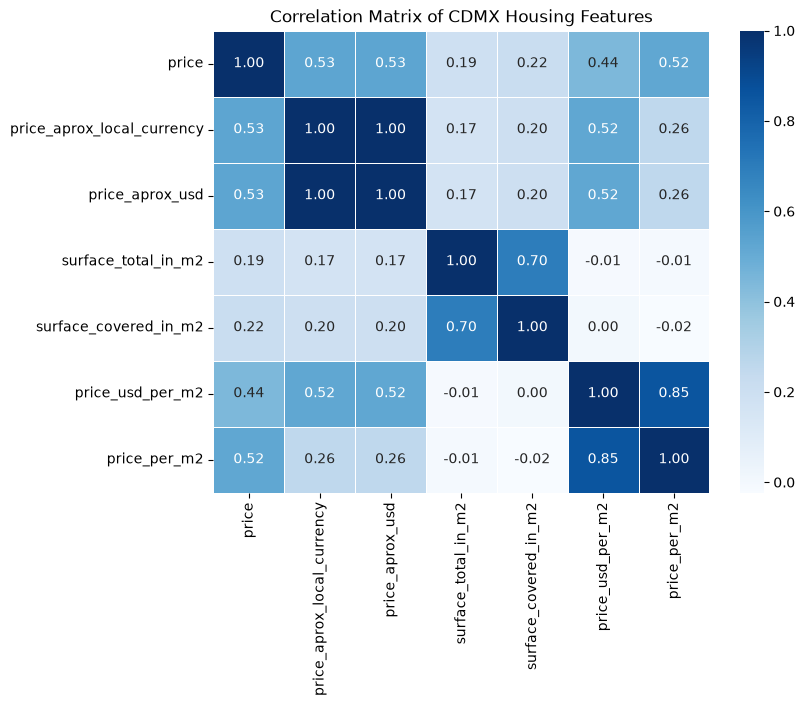

In [23]:
correlation_matrix =df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of CDMX Housing Features')
plt.show()

## **extract KPIs**

In [24]:
total_properties = len(df)
avg_price_usd = df['price_aprox_usd'].mean()
avg_price_m2_usd = df['price_usd_per_m2'].mean()

print(f"Total Properties: {total_properties:,.0f}")
print(f"Average Property Price: ${avg_price_usd:,.2f}")
print(f"Average Price per m²: ${avg_price_m2_usd:,.2f}")

Total Properties: 15,152
Average Property Price: $292,406.66
Average Price per m²: $1,497.03


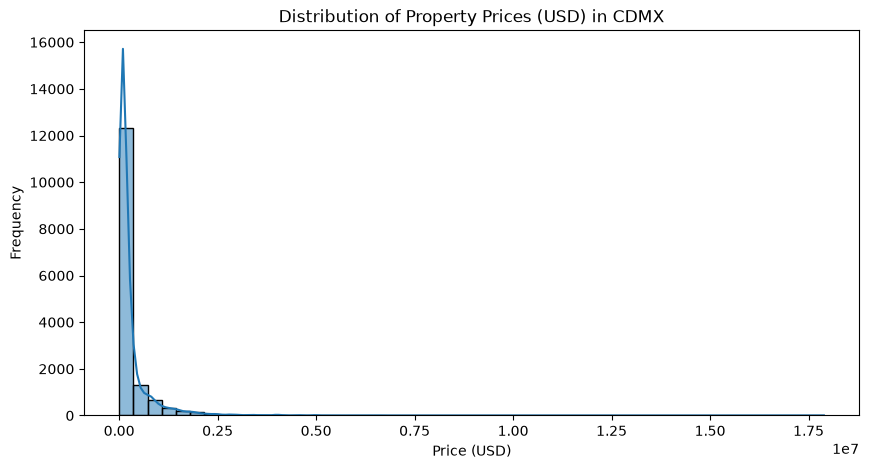

In [25]:
# Plot the distribution of property prices
plt.figure(figsize=(10, 5))
sns.histplot(df['price_aprox_usd'], bins=50, kde=True)
plt.title('Distribution of Property Prices (USD) in CDMX')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

## **Property Type Insights**

In [26]:
# Aggregate data by property type
type_insights = df.groupby('property_type').agg(
    property_count=('property_type', 'count'),
    avg_price_usd=('price_aprox_usd', 'mean'),
    avg_price_per_m2=('price_usd_per_m2', 'mean')
).round(2).sort_values(by='avg_price_usd', ascending=False)
display(type_insights)



,property_count,avg_price_usd,avg_price_per_m2
property_type,,,
PH,14,753263.59,2828.94
store,151,541455.69,2195.53
house,4473,425417.01,1262.44
apartment,10514,231629.26,1585.03


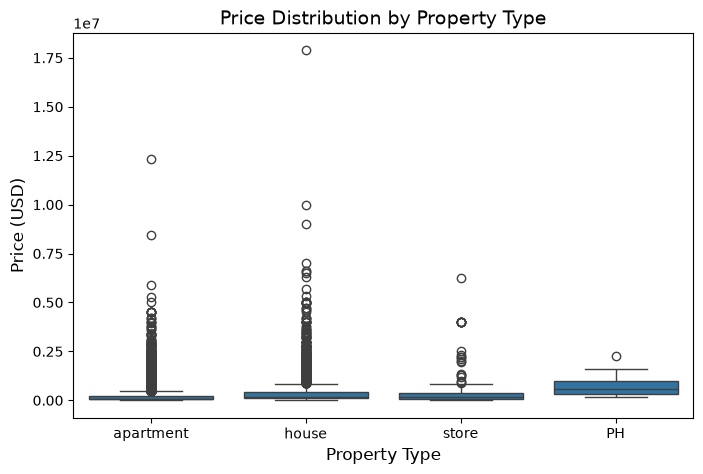

In [27]:
# Plot price distribution by property type to spot outliers
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='property_type', y='price_aprox_usd')
plt.title('Price Distribution by Property Type', fontsize=14)
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.show()

## ****Top Places Analysis****

In [28]:
# Extract the most expensive places by price
borough_prices = df.groupby('places')['price_aprox_usd'].mean().round(2).sort_values(ascending=True)
borough_prices

places
Tlahuac                62490.02
Iztacalco              73169.58
Iztapalapa             78686.45
VenustianoCarranza     79975.52
MilpaAlta              85635.80
Azcapotzalco           96644.93
GustavoAMadero        115078.46
Xochimilco            162314.94
Cuauhtemoc            168264.91
BenitoJuarez          179119.82
Coyoacan              190644.59
Tlalpan               279163.10
MagdalenaContreras    330846.78
AlvaroObregon         346097.27
MiguelHidalgo         771885.81
Cuajimalpa            787876.64
Name: price_aprox_usd, dtype: float64

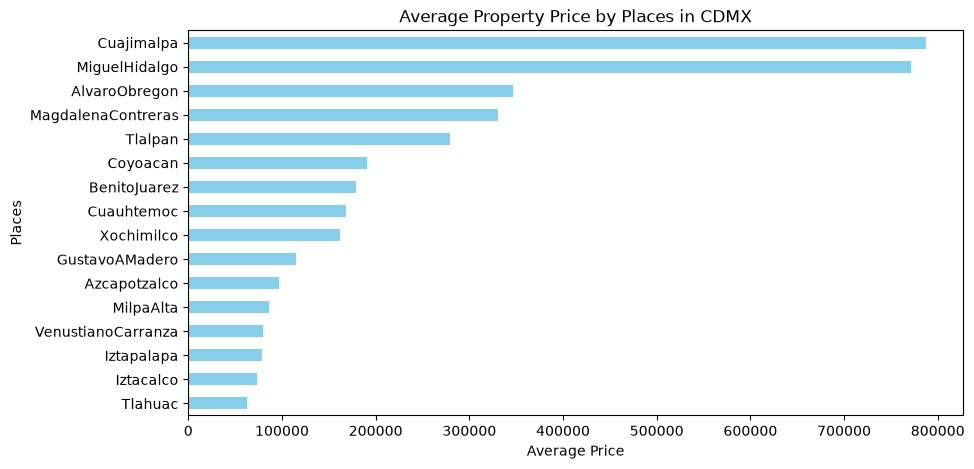

In [29]:
plt.figure(figsize=(10, 5))
borough_prices.plot(kind='barh', color='skyblue')
plt.title('Average Property Price by Places in CDMX')
plt.xlabel('Average Price')
plt.ylabel('Places')
plt.show()

In [30]:
# Extract the top 10 most expensive places by price per square meter
top_10_places = df.groupby('places')['price_usd_per_m2'].mean().sort_values(ascending=False).head(10)
top_10_places.round(2)

places
MiguelHidalgo         2689.51
Cuajimalpa            2265.13
BenitoJuarez          1657.83
AlvaroObregon         1468.98
Cuauhtemoc            1437.60
MagdalenaContreras    1290.55
Coyoacan              1233.00
Tlalpan               1157.43
Azcapotzalco           884.60
VenustianoCarranza     850.17
Name: price_usd_per_m2, dtype: float64

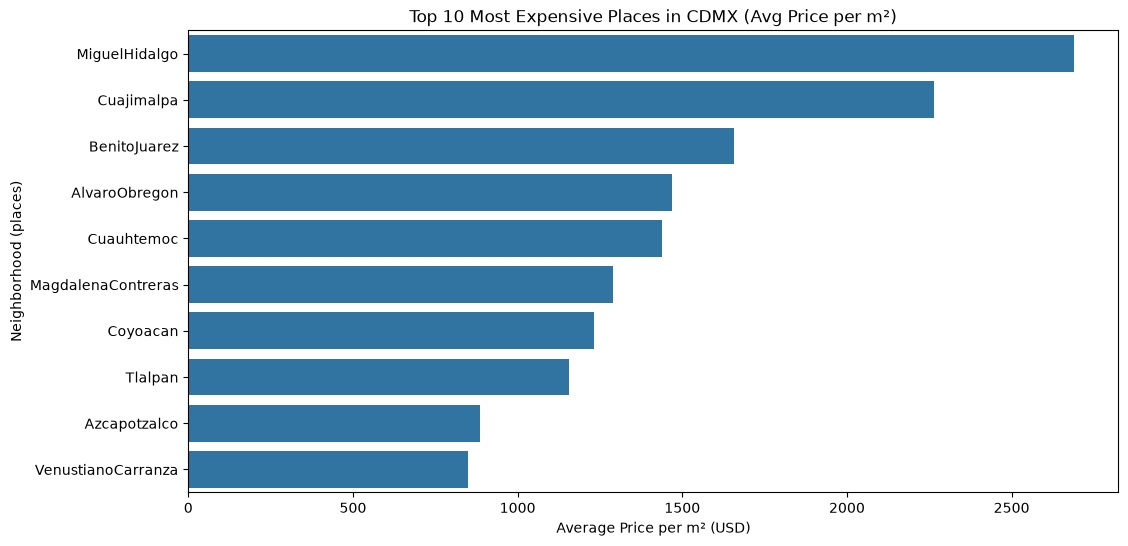

In [31]:
# Visualize the top 10 places using a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_places.values, y=top_10_places.index)
plt.title('Top 10 Most Expensive Places in CDMX (Avg Price per m²)')
plt.xlabel('Average Price per m² (USD)')
plt.ylabel('Neighborhood (places)')
plt.show()

**Surface Area vs. Price Correlation**

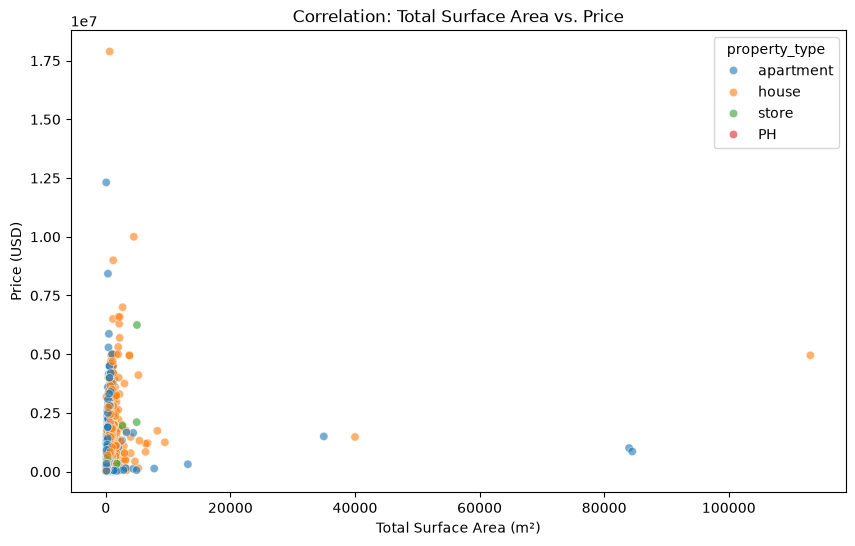

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='surface_total_in_m2', y='price_aprox_usd', hue='property_type', alpha=0.6)
plt.title('Correlation: Total Surface Area vs. Price', )
plt.xlabel('Total Surface Area (m²)')
plt.ylabel('Price (USD)')
plt.show()

**Create a new column classifying the property: Does it have an outdoor space or not?**

In [33]:
df["has_garden"]=df["surface_total_in_m2"]-df["surface_covered_in_m2"]
df["has_garden"]=df["has_garden"].apply(lambda x: "Yes" if x > 0 else "No")
df["has_garden"].head()

0    No
1    No
2    No
3    No
4    No
Name: has_garden, dtype: str

In [34]:
garden_prices = df.groupby('has_garden')['price_aprox_usd'].mean().round(2)
garden_prices

has_garden
No     262298.50
Yes    892407.43
Name: price_aprox_usd, dtype: float64

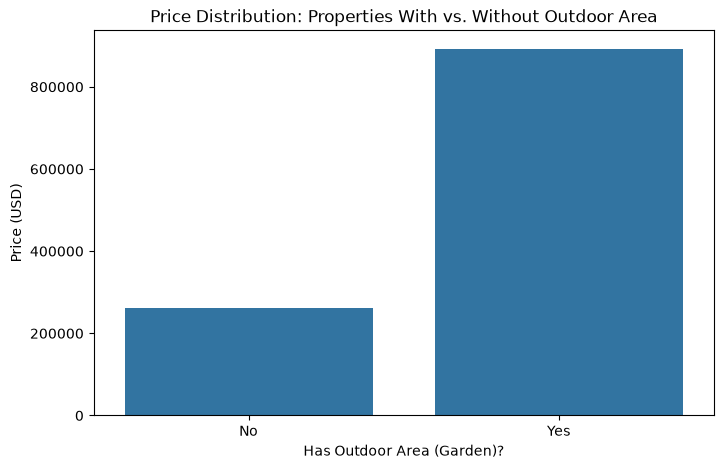

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(x=garden_prices.index, y=garden_prices.values)
plt.title('Price Distribution: Properties With vs. Without Outdoor Area')
plt.xlabel('Has Outdoor Area (Garden)?')
plt.ylabel('Price (USD)')
plt.show()

In [36]:
df.drop(columns=['price_aprox_local_currency','price',"price_per_m2","surface_covered_in_m2"], inplace=True)

In [37]:
df.to_csv(r'C:\Users\besho\OneDrive\Desktop\project\SIC_P1\dataset\housing_data_CDMX_cleaned.csv', index=False)